# População: denominadores confiáveis, pirâmides etárias e padronização por idade

**A pergunta:** toda taxa em saúde é uma divisão. O numerador vem do SIM, do
SINAN, do SIH… e o denominador vem daqui. Este notebook mostra como obter a
população brasileira pelo PySUS, **conferir se ela está íntegra** (dois anos
recentes vêm truncados na origem, e ninguém avisa) e usá-la para comparar
lugares de forma honesta, com padronização por idade.

**Fonte:** IBGE, via DATASUS/PySUS — projeções por UF, idade e sexo (2000–2070)
e estimativas municipais (1992–2025).

**Tempo estimado:** 3 a 5 minutos.

**O que você leva daqui:** duas funções reaproveitáveis — uma que confere a
integridade do arquivo de população e outra que calcula taxas padronizadas
pela População Padrão Mundial da OMS, comparáveis com a literatura
internacional.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


In [4]:
# ---- Uma armadilha do catálogo, e como escapar dela --------------------
# O parâmetro state= diz onde PROCURAR, e não filtra: a PySUS devolve o arquivo
# NACIONAL ao lado do arquivo do estado. Pior, para 2025 e 2026 ela devolve
# SÓ o nacional. Pegar o primeiro da lista entrega o Brasil inteiro rotulado
# como estado — era o que este notebook fazia, e a mortalidade saía três vezes
# menor do que é.
import os

from pysus import list_files


def arquivo_da_uf(arquivos, uf, prefixo):
    """Entre os arquivos devolvidos, o DO ESTADO. Falha alto se não houver."""
    do_estado = [str(a) for a in arquivos
                 if os.path.basename(str(a)).upper().startswith(
                     f"{prefixo}{uf}".upper())]
    if not do_estado:
        nacionais = [os.path.basename(str(a)) for a in arquivos]
        raise ValueError(
            f"Não existe arquivo de {uf} para este ano: a PySUS ofereceu só "
            f"{nacionais}, que é nacional. Use ano_com_arquivo_da_uf() para "
            "escolher um ano que tenha arquivo estadual.")
    return do_estado[0].replace("\\", "/")


def ano_com_arquivo_da_uf(base, uf, prefixo, ate=None):
    """O ano mais recente COM arquivo do estado — que é também um ano fechado.

    Anos em andamento (2025, 2026) só têm o arquivo nacional, e ainda por cima
    estão incompletos: contar óbitos neles subestima tudo.
    """
    catalogo = list_files(dataset=base, state=uf)
    anos = []
    for nome, ano in zip(catalogo["name"], catalogo["year"]):
        if ano != ano:            # NaN
            continue
        if os.path.basename(str(nome)).upper().startswith(f"{prefixo}{uf}".upper()):
            if ate is None or int(ano) <= int(ate):
                anos.append(int(ano))
    if not anos:
        raise ValueError(f"Nenhum ano de {base} tem arquivo de {uf}.")
    return max(anos)

## 1. O que você pode trocar

Estes são os únicos valores que o notebook usa como escolha sua.

In [5]:
UF_ALVO = "PR"        # estado das pirâmides e do exemplo de padronização
ANO = 2024            # ano de referência (o mais recente com dado completo)
ANO_PASSADO = 2000    # para comparar a forma da pirâmide no tempo
ANO_FUTURO = 2050     # projeção do IBGE

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}
CODIGO_UF = {sigla: codigo for codigo, sigla in UFS.items()}

print(f"Estado: {UF_ALVO} (código {CODIGO_UF[UF_ALVO]}) — ano de referência: {ANO}")

Estado: PR (código 41) — ano de referência: 2024


## 2. O que o IBGE oferece dentro do PySUS

Antes de baixar qualquer coisa, vale ver o catálogo. Ele revela que existem
**dois produtos bem diferentes** com o mesmo nome de "população".

In [6]:
import re
from pysus import list_files

catalogo = list_files(dataset="ibge")
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/")) for n in catalogo["name"]]
catalogo["tipo"] = [re.match(r"[A-Z]+", a).group(0) for a in catalogo["arquivo"]]

resumo = (
    catalogo.groupby("tipo")
    .agg(arquivos=("arquivo", "size"), primeiro_ano=("year", "min"), ultimo_ano=("year", "max"))
    .sort_values("arquivos", ascending=False)
)

DESCRICAO = {
    "PROJUF": "Projeção por UF, idade simples e sexo — a base das pirâmides e das taxas",
    "POPTBR": "População total por município — o denominador de taxas municipais",
    "POPBR": "População por município e faixa etária (série antiga)",
    "IDOSOBR": "População idosa (censos)",
    "ESCABR": "Escolaridade — alfabetizados",
    "ESCBBR": "Escolaridade — anos de estudo",
    "ALFBR": "Alfabetização",
    "RENDABR": "Renda",
}
resumo["o que é"] = [DESCRICAO.get(t, "") for t in resumo.index]
resumo

,arquivos,primeiro_ano,ultimo_ano,o que é
tipo,,,,
PROJUF,71,2000,2070,"Projeção por UF, idade simples e sexo — a base..."
POPBR,33,1980,2012,População por município e faixa etária (série ...
POPTBR,33,1992,2025,População total por município — o denominador ...
ALFBR,3,1991,2010,Alfabetização
IDOSOBR,3,1991,2010,População idosa (censos)
ESCBBR,3,1991,2010,Escolaridade — anos de estudo
ESCABR,3,1991,2010,Escolaridade — alfabetizados
RENDABR,3,1991,2010,Renda


Repare no alcance: as **projeções (PROJUF) vão até 2070**. Isso permite
responder perguntas de planejamento — quantos idosos o estado terá em 2040? —
com o mesmo código que analisa o presente.

In [7]:
from pysus import ibge

arquivos = ibge(year=ANO)
for caminho in arquivos:
    tamanho = os.path.getsize(caminho) / 1024
    print(f"{os.path.basename(caminho):<18} {tamanho:>8.0f} KB")

def caminho_de(arquivos, prefixo):
    "Escolhe, entre os arquivos baixados, o que começa com o prefixo pedido."
    for caminho in arquivos:
        if os.path.basename(caminho).startswith(prefixo):
            return caminho.replace("\\", "/")
    raise FileNotFoundError(f"Nenhum arquivo {prefixo} para este ano.")

PROJUF24.parquet         38 KB
POPTBR24.parquet         74 KB


## 3. A armadilha: o arquivo municipal pode vir pela metade

Um mesmo ano pode ter o arquivo de projeções completo e o arquivo municipal
truncado. Nada avisa: o download termina normalmente, a tabela abre, as contas
rodam — e o resultado sai errado.

A conferência é simples: **um arquivo municipal íntegro tem 5.570 municípios
distribuídos em 27 unidades da federação.** Se tiver menos, não use.

In [8]:
def conferir_populacao_municipal(ano, verboso=True):
    """Baixa a população municipal do ano e diz se o arquivo está íntegro.

    Devolve (esta_integro, tabela). Use sempre antes de calcular taxa municipal.
    """
    caminho = caminho_de(ibge(year=ano), "POPT")
    tabela = con.execute(f"SELECT * FROM read_parquet('{caminho}')").df()
    tabela["POPULACAO"] = pd.to_numeric(tabela["POPULACAO"], errors="coerce")
    tabela["UF"] = tabela["MUNIC_RES"].astype(str).str[:2].astype(int).map(UFS)

    municipios = len(tabela)
    unidades = tabela["UF"].nunique()
    integro = unidades >= 27 and municipios >= 5000

    if verboso:
        selo = "OK" if integro else "INCOMPLETO"
        print(f"{ano}: {mil(municipios):>6} municípios em {unidades:>2} UFs — {selo}")
        if not integro:
            print(f"       só contém: {sorted(tabela['UF'].dropna().unique())}")
    return integro, tabela

print("Conferindo os anos recentes:\n")
for ano in [2020, 2021, 2022, 2023, 2024, 2025]:
    conferir_populacao_municipal(ano)

Conferindo os anos recentes:


2020:  5.570 municípios em 27 UFs — OK


2021:  5.570 municípios em 27 UFs — OK


2022:    399 municípios em  1 UFs — INCOMPLETO
       só contém: ['PR']


2023:    167 municípios em  1 UFs — INCOMPLETO
       só contém: ['RN']


2024:  5.570 municípios em 27 UFs — OK


2025:  5.571 municípios em 27 UFs — OK


Está aí o problema, e ele é real: **2022 traz apenas o Paraná e 2023 apenas o
Rio Grande do Norte.** Quem calculasse mortalidade infantil municipal de 2022
sem conferir teria juntado óbitos do país inteiro com a população de um estado
só — e publicado uma taxa dezenas de vezes maior que a verdadeira.

Quando o ano que você precisa estiver truncado, há duas saídas: usar o ano
completo mais próximo (dizendo isso no texto do trabalho) ou trabalhar por UF,
com as projeções, que estão íntegras em todos os anos.

In [9]:
integro, populacao_municipal = conferir_populacao_municipal(ANO, verboso=False)
assert integro, f"O arquivo municipal de {ANO} não está íntegro — escolha outro ano."

maiores = (
    populacao_municipal.nlargest(10, "POPULACAO")[["MUNIC_RES", "UF", "POPULACAO"]]
    .assign(POPULACAO=lambda d: d["POPULACAO"].astype(int))
    .reset_index(drop=True)
)
print(f"População do Brasil em {ANO}: {mil(populacao_municipal['POPULACAO'].sum())}")
print("\nOs dez municípios mais populosos (código do IBGE de 7 dígitos):")
maiores

População do Brasil em 2024: 212.583.750
Os dez municípios mais populosos (código do IBGE de 7 dígitos):


,MUNIC_RES,UF,POPULACAO
0,3550308,SP,11895578
1,3304557,RJ,6729894
2,5300108,DF,2982818
3,2304400,CE,2574412
4,2927408,BA,2568928
5,3106200,MG,2416339
6,1302603,AM,2279686
7,4106902,PR,1829225
8,2611606,PE,1587707
9,5208707,GO,1494599


## 4. Pirâmide etária: a forma da população

As projeções trazem população por **idade simples** (0 a 90+) e sexo. Agrupar
de cinco em cinco anos é a convenção que permite comparar com qualquer estudo
publicado.

In [10]:
FAIXAS = [(i, i + 4) for i in range(0, 90, 5)] + [(90, 199)]
ROTULOS = [f"{a}-{b}" for a, b in FAIXAS[:-1]] + ["90+"]

def populacao_por_faixa(ano, uf=None):
    """População por faixa etária quinquenal e sexo.

    uf=None devolve o Brasil inteiro; uf='PR' devolve um estado.
    """
    caminho = caminho_de(ibge(year=ano), "PROJ")
    filtro = f"WHERE CAST(UFCOD AS INTEGER) = {CODIGO_UF[uf]}" if uf else ""
    bruto = con.execute(f"""
        SELECT CAST(substr(IDADE, 2, 2) AS INTEGER) AS idade,
               SEXO,
               sum(CAST(POPULACAO AS BIGINT)) AS populacao
        FROM read_parquet('{caminho}') {filtro}
        GROUP BY 1, 2
    """).df()

    limites = [a for a, _ in FAIXAS] + [200]
    bruto["faixa"] = pd.cut(bruto["idade"], bins=limites, right=False, labels=ROTULOS)
    tabela = (
        bruto.pivot_table(index="faixa", columns="SEXO", values="populacao",
                          aggfunc="sum", observed=False)
        .rename(columns={"M": "Homens", "F": "Mulheres"})
        .reindex(ROTULOS)
        .fillna(0)
        .astype(int)
    )
    return tabela

piramide = populacao_por_faixa(ANO, UF_ALVO)
print(f"{UF_ALVO} em {ANO}: {mil(piramide.values.sum())} habitantes")
piramide.tail(8)

PR em 2024: 11.824.665 habitantes


SEXO,Mulheres,Homens
faixa,,
55-59,380354,338958
60-64,336111,289603
65-69,271675,227927
70-74,206858,166564
75-79,142589,109486
80-84,87810,61963
85-89,46154,29403
90+,23355,12187


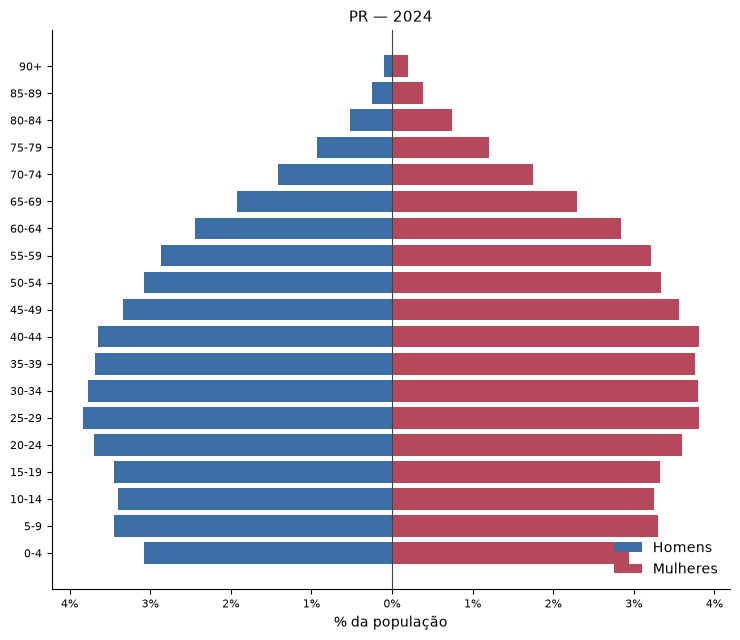

In [11]:
def desenhar_piramide(tabela, titulo, eixo=None, cor_h="#3b6ea5", cor_m="#b5495b"):
    eixo = eixo or plt.subplots(figsize=(7, 6))[1]
    total = tabela.values.sum()
    homens = -tabela["Homens"] / total * 100
    mulheres = tabela["Mulheres"] / total * 100

    eixo.barh(tabela.index, homens, color=cor_h, label="Homens")
    eixo.barh(tabela.index, mulheres, color=cor_m, label="Mulheres")
    eixo.axvline(0, color="#444", linewidth=0.8)
    eixo.set_title(titulo, fontsize=11)
    eixo.set_xlabel("% da população")
    eixo.xaxis.set_major_formatter(lambda v, _: f"{abs(v):.0f}%")
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.tick_params(labelsize=8)
    return eixo

figura, eixo = plt.subplots(figsize=(7.5, 6.5))
desenhar_piramide(piramide, f"{UF_ALVO} — {ANO}", eixo)
eixo.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 5. A transição demográfica em três retratos

A mesma função, três anos. É aqui que os dados deixam de ser tabela e viram
história: a base larga de 2000 (muitas crianças) some, e o topo engorda.

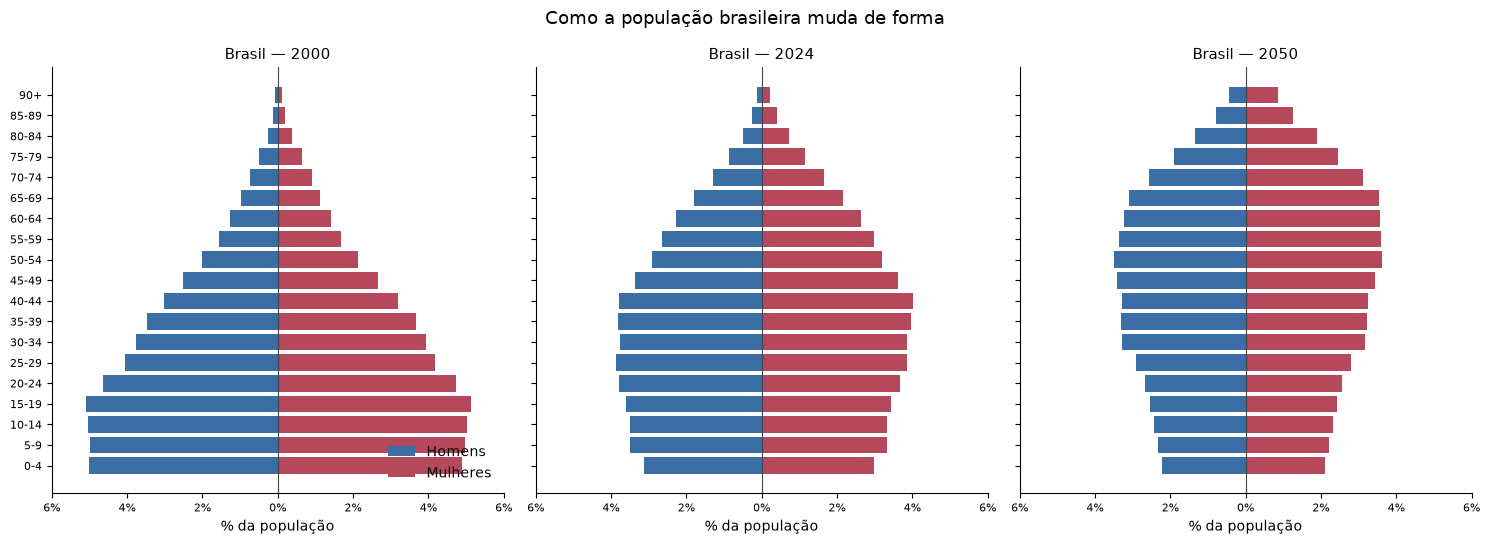

In [12]:
anos = [ANO_PASSADO, ANO, ANO_FUTURO]
figura, eixos = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)

for eixo, ano in zip(eixos, anos):
    tabela = populacao_por_faixa(ano)          # Brasil inteiro
    desenhar_piramide(tabela, f"Brasil — {ano}", eixo)
    eixo.set_xlim(-6, 6)

eixos[0].legend(loc="lower right", frameon=False)
plt.suptitle("Como a população brasileira muda de forma", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Indicadores demográficos por estado

Três números resumem essas pirâmides e são usados em qualquer diagnóstico de
saúde regional:

- **Razão de dependência** — quantas pessoas fora da idade de trabalhar
  (0–14 e 65+) existem para cada 100 em idade de trabalhar. Pressiona
  previdência e cuidado.
- **Índice de envelhecimento** — idosos (60+) para cada 100 crianças (0–14).
- **Proporção de idosos** — a fatia com 60 anos ou mais.

In [13]:
def indicadores_demograficos(ano, uf):
    caminho = caminho_de(ibge(year=ano), "PROJ")
    dados = con.execute(f"""
        SELECT CAST(substr(IDADE, 2, 2) AS INTEGER) AS idade,
               sum(CAST(POPULACAO AS BIGINT)) AS populacao
        FROM read_parquet('{caminho}')
        WHERE CAST(UFCOD AS INTEGER) = {CODIGO_UF[uf]}
        GROUP BY 1
    """).df()

    def soma(minimo, maximo):
        recorte = dados[(dados["idade"] >= minimo) & (dados["idade"] <= maximo)]
        return int(recorte["populacao"].sum())

    criancas, ativos, idosos65, idosos60 = soma(0, 14), soma(15, 64), soma(65, 199), soma(60, 199)
    total = soma(0, 199)
    return {
        "UF": uf,
        "População": total,
        "Razão de dependência": round((criancas + idosos65) / ativos * 100, 1),
        "Índice de envelhecimento": round(idosos60 / criancas * 100, 1),
        "% com 60+": round(idosos60 / total * 100, 1),
    }

painel = pd.DataFrame([indicadores_demograficos(ANO, uf) for uf in UFS.values()])
painel = painel.sort_values("Índice de envelhecimento", ascending=False).reset_index(drop=True)

print(f"Estados por envelhecimento, {ANO}\n")
pd.concat([painel.head(5), painel.tail(5)])

Estados por envelhecimento, 2024


,UF,População,Razão de dependência,Índice de envelhecimento,% com 60+
0,RS,11229915,47.6,116.5,20.6
1,RJ,17219679,45.3,105.5,18.9
2,MG,21322691,44.4,102.1,18.3
3,SP,45973194,44.3,92.0,17.2
4,PR,11824665,45.2,87.6,17.0
22,PA,8664306,44.8,47.4,11.1
23,AC,880631,47.4,37.3,9.6
24,AM,4281209,48.7,34.8,9.3
25,AP,802837,48.0,32.0,8.6
26,RR,716793,51.1,28.9,8.2


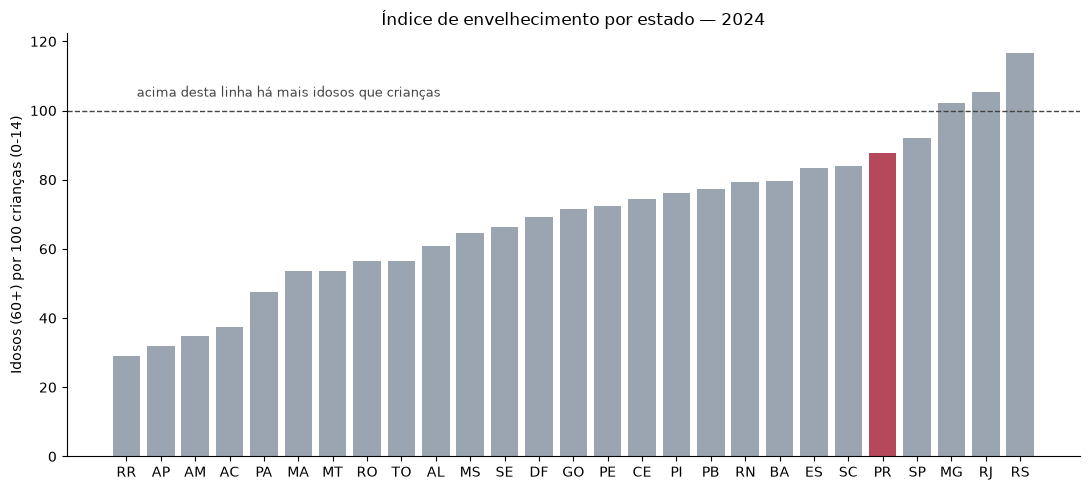

In [14]:
ordenado = painel.sort_values("Índice de envelhecimento")
cores = ["#b5495b" if uf == UF_ALVO else "#9aa5b1" for uf in ordenado["UF"]]

figura, eixo = plt.subplots(figsize=(11, 5))
eixo.bar(ordenado["UF"], ordenado["Índice de envelhecimento"], color=cores)
eixo.set_ylabel("Idosos (60+) por 100 crianças (0-14)")
eixo.set_title(f"Índice de envelhecimento por estado — {ANO}", fontsize=12)
eixo.axhline(100, color="#444", linestyle="--", linewidth=1)
eixo.text(0.3, 104, "acima desta linha há mais idosos que crianças",
          fontsize=9, color="#444")
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Padronização por idade: comparar lugares sem enganação

Este é o motivo pelo qual o notebook existe.

Um estado envelhecido morre mais — não porque adoeça mais, mas porque tem mais
idosos. Comparar taxas brutas entre lugares de estruturas etárias diferentes é
um erro clássico. A padronização resolve: calcula-se a taxa **em cada faixa
etária** e aplica-se essas taxas a uma **população padrão única**, a mesma para
todos os lugares comparados.

Usamos a **População Padrão Mundial da OMS**, que é o padrão adotado
internacionalmente — assim seu resultado é comparável com estudos de qualquer
país.

In [15]:
# População Padrão Mundial da OMS (percentuais por faixa quinquenal).
PADRAO_OMS = {
    "0-4": 8.86, "5-9": 8.69, "10-14": 8.60, "15-19": 8.47, "20-24": 8.22,
    "25-29": 7.93, "30-34": 7.61, "35-39": 7.15, "40-44": 6.59, "45-49": 6.04,
    "50-54": 5.37, "55-59": 4.55, "60-64": 3.72, "65-69": 2.96, "70-74": 2.21,
    "75-79": 1.52, "80-84": 0.91, "85-89": 0.44, "90+": 0.195,
}
peso_padrao = pd.Series(PADRAO_OMS)
peso_padrao = peso_padrao / peso_padrao.sum()      # soma exatamente 1

def taxa_padronizada(eventos, populacao, por=100_000):
    """Taxa padronizada por idade, método direto, padrão OMS.

    eventos e populacao: Series indexadas pelas faixas etárias (mesmos rótulos).
    Devolve (taxa_bruta, taxa_padronizada), ambas por 100 mil habitantes.
    """
    eventos = eventos.reindex(ROTULOS).fillna(0)
    populacao = populacao.reindex(ROTULOS).fillna(0)

    bruta = eventos.sum() / populacao.sum() * por
    taxas_por_faixa = (eventos / populacao.replace(0, pd.NA)).fillna(0)
    padronizada = (taxas_por_faixa * peso_padrao).sum() * por
    return round(bruta, 1), round(padronizada, 1)

print("Padrão da OMS carregado — soma dos pesos:", round(peso_padrao.sum(), 6))
peso_padrao.head(4)

Padrão da OMS carregado — soma dos pesos: 1.0


0-4      0.088569
5-9      0.086870
10-14    0.085970
15-19    0.084670
dtype: float64

### Demonstração com dados reais de mortalidade

Vamos comparar dois estados de estruturas etárias opostas: o **Rio Grande do
Sul**, o mais envelhecido, e o **Amapá**, o mais jovem. A pergunta é se o Rio
Grande do Sul realmente "morre mais".

In [16]:
from pysus import sim

def idade_em_anos(codigo):
    """Traduz o código de idade do SIM (3 dígitos) para anos completos.

    O primeiro dígito é a unidade: 0-3 são minutos, horas, dias e meses
    (ou seja, menos de um ano); 4 são anos; 5 são anos acima de cem.
    """
    texto = str(codigo).strip()
    if len(texto) < 3 or not texto[:3].isdigit():
        return None
    unidade, valor = int(texto[0]), int(texto[1:3])
    if unidade == 5:
        return 100 + valor
    if unidade == 4:
        return valor
    return 0

def obitos_por_faixa(uf, ano):
    caminho = arquivo_da_uf(sim(uf, ano), uf, "DO")
    idades = con.execute(f"SELECT IDADE FROM read_parquet('{caminho}')").df()
    anos = idades["IDADE"].map(idade_em_anos).dropna()
    limites = [a for a, _ in FAIXAS] + [200]
    faixas = pd.cut(anos, bins=limites, right=False, labels=ROTULOS)
    return faixas.value_counts().reindex(ROTULOS).fillna(0)

comparacao = []
for uf in ["RS", "AP"]:
    eventos = obitos_por_faixa(uf, ANO - 1)          # último ano fechado do SIM
    populacao = populacao_por_faixa(ANO - 1, uf).sum(axis=1)
    bruta, padronizada = taxa_padronizada(eventos, populacao)
    comparacao.append({
        "UF": uf,
        "Óbitos": int(eventos.sum()),
        "População": int(populacao.sum()),
        "Taxa bruta": bruta,
        "Taxa padronizada": padronizada,
    })

comparacao = pd.DataFrame(comparacao)
comparacao

,UF,Óbitos,População,Taxa bruta,Taxa padronizada
0,RS,93516,11222292,833.3,546.2
1,AP,3926,799124,491.3,629.7


Leia a tabela com atenção — ela é a lição inteira do notebook.

Pela **taxa bruta**, o Rio Grande do Sul parece muito pior. Depois de
padronizar, a distância encolhe ou inverte: boa parte do que parecia excesso de
mortalidade era, na verdade, excesso de idade. Publicar a taxa bruta como se
fosse comparação entre estados é um erro que aparece com frequência em relatórios
locais.

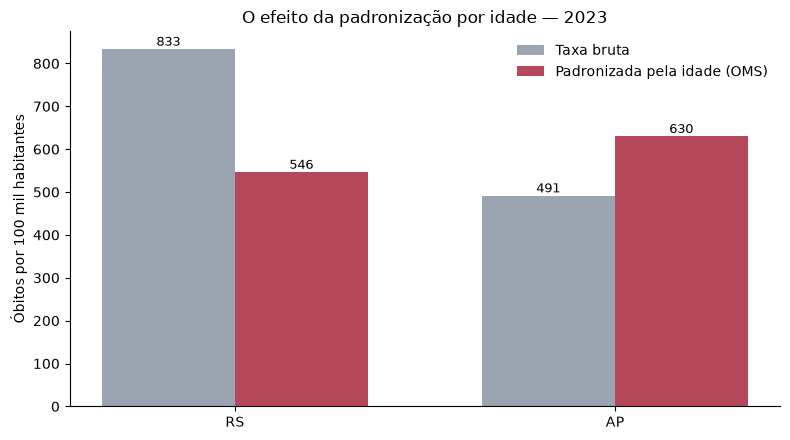

In [17]:
figura, eixo = plt.subplots(figsize=(8, 4.5))
largura = 0.35
posicoes = range(len(comparacao))

eixo.bar([p - largura / 2 for p in posicoes], comparacao["Taxa bruta"],
         largura, label="Taxa bruta", color="#9aa5b1")
eixo.bar([p + largura / 2 for p in posicoes], comparacao["Taxa padronizada"],
         largura, label="Padronizada pela idade (OMS)", color="#b5495b")

eixo.set_xticks(list(posicoes))
eixo.set_xticklabels(comparacao["UF"])
eixo.set_ylabel("Óbitos por 100 mil habitantes")
eixo.set_title(f"O efeito da padronização por idade — {ANO - 1}", fontsize=12)
eixo.legend(frameon=False)
eixo.spines[["top", "right"]].set_visible(False)

for posicao, linha in zip(posicoes, comparacao.itertuples()):
    eixo.text(posicao - largura / 2, linha._4 + 8, f"{linha._4:.0f}",
              ha="center", fontsize=9)
    eixo.text(posicao + largura / 2, linha._5 + 8, f"{linha._5:.0f}",
              ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Conferindo com a realidade

Números só valem se batem com a fonte oficial. Três verificações:

In [18]:
brasil = populacao_por_faixa(ANO)
total_brasil = brasil.values.sum()
razao_sexos = brasil["Homens"].sum() / brasil["Mulheres"].sum() * 100

print(f"População do Brasil em {ANO}")
print(f"  projeções (PROJUF): {mil(total_brasil)}")
print(f"  estimativas municipais somadas: {mil(populacao_municipal['POPULACAO'].sum())}")
print(f"  IBGE, divulgação oficial: cerca de 212,6 milhões")
print()
print(f"Razão de sexos: {razao_sexos:.1f} homens para cada 100 mulheres "
      f"(o esperado no Brasil é entre 94 e 96)")
print()
print(f"Diferença entre as duas fontes: "
      f"{abs(total_brasil - populacao_municipal['POPULACAO'].sum()) / total_brasil * 100:.2f}%")

População do Brasil em 2024
  projeções (PROJUF): 212.583.750
  estimativas municipais somadas: 212.583.750
  IBGE, divulgação oficial: cerca de 212,6 milhões
Razão de sexos: 95.2 homens para cada 100 mulheres (o esperado no Brasil é entre 94 e 96)
Diferença entre as duas fontes: 0.00%


## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF_ALVO = "SP"` |
| O Brasil inteiro nas pirâmides | `populacao_por_faixa(ANO)` sem o segundo argumento |
| Olhar o futuro | `ANO_FUTURO = 2070` — as projeções vão até lá |
| Denominador de um município | use `populacao_municipal`, filtrando `MUNIC_RES` |
| Padrão brasileiro em vez do mundial | troque `PADRAO_OMS` pelos percentuais de `populacao_por_faixa(2010)` |
| Taxa específica de um sexo | passe só a coluna `Homens` ou `Mulheres` para `taxa_padronizada` |

### As duas funções que valem levar

`conferir_populacao_municipal(ano)` — antes de qualquer taxa municipal.
`taxa_padronizada(eventos, populacao)` — antes de qualquer comparação entre lugares.

Elas reaparecem nos notebooks de mortalidade e de internações deste repositório.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: IBGE e SIM, via DATASUS e biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [19]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "A pirâmide tem as faixas etárias", len(piramide) > 0,
         f"{len(piramide)} faixas")
# 'piramide' e do UF_ALVO e 'brasil' e do pais: comparar as duas era erro meu.
conferir(2, "A pirâmide do estado soma menos que o Brasil",
         piramide.values.sum() < total_brasil,
         f"{piramide.values.sum():,.0f} de {total_brasil:,.0f}")
conferir(3, "População do Brasil na ordem de grandeza certa",
         150e6 < total_brasil < 260e6, f"{total_brasil:,.0f} habitantes")
# razao_sexos ja vem multiplicada por 100: e "homens por 100 mulheres".
conferir(4, "Homens por 100 mulheres entre 90 e 110",
         90 < razao_sexos < 110, f"{razao_sexos:.1f} homens por 100 mulheres")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. A pirâmide tem as faixas etárias — 19 faixas: confere
2. A pirâmide do estado soma menos que o Brasil — 11,824,665 de 212,583,750: confere
3. População do Brasil na ordem de grandeza certa — 212,583,750 habitantes: confere
4. Homens por 100 mulheres entre 90 e 110 — 95.2 homens por 100 mulheres: confere
Tudo confere.
